# 1. Imports & Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from src.db import run_query, get_connection
from src.features import get_feature_columns, get_target_columns, build_features

# 2. Load Model Data

In [2]:
df = run_query("SELECT * FROM analytics.model_features").copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print(df.shape)
print(df["time"].min(), "→", df["time"].max())
df.head()

(10955, 20)
2020-04-28 00:00:00 → 2026-04-27 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
0,2020-04-28,14.6,0.0,42.0,83,71,11.9,38436.84,Baku,4,28,19.3,0.0,15.9,78.0,16.950000,0.0,28.950000,80.500000,0
1,2020-04-29,17.6,0.0,22.4,61,50,16.3,39311.92,Baku,4,29,14.6,0.0,42.0,83.0,17.166667,0.0,26.766667,74.000000,0
2,2020-04-30,18.0,0.0,23.0,77,50,16.0,44363.33,Baku,4,30,17.6,0.0,22.4,61.0,16.733333,0.0,29.133333,74.750000,0
3,2020-05-01,19.5,0.0,20.2,78,24,18.5,46341.87,Baku,5,1,18.0,0.0,23.0,77.0,18.366667,0.0,21.866667,75.400000,0
4,2020-05-02,19.6,0.0,20.7,83,45,19.0,43993.52,Baku,5,2,19.5,0.0,20.2,78.0,19.033333,0.0,21.300000,76.666667,0


# 3. Core Helper Functions

## 3.1 — supervised dataset

In [3]:
def make_supervised(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Create supervised dataset for a specific forecast horizon.

    time = origin date
    target_time = date being predicted
    """
    out = df.copy().sort_values(["city", "time"]).reset_index(drop=True)

    out["target_time"] = out.groupby("city")["time"].shift(-horizon)

    for col in get_target_columns():
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)

    out = out.dropna().reset_index(drop=True)

    out["target_month"] = out["target_time"].dt.month
    out["target_day_of_month"] = out["target_time"].dt.day
    out["target_day_of_year"] = out["target_time"].dt.dayofyear

    out["target_day_sin"] = np.sin(2 * np.pi * out["target_day_of_year"] / 365.25)
    out["target_day_cos"] = np.cos(2 * np.pi * out["target_day_of_year"] / 365.25)

    return out

## 3.2 — metrics

In [4]:
def evaluate_multitarget(y_true: pd.DataFrame, y_pred: np.ndarray, target_names):
    rows = []

    for i, target in enumerate(target_names):
        yt = y_true.iloc[:, i]
        yp = y_pred[:, i]

        rows.append({
            "target": target,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
        })

    return pd.DataFrame(rows)

## 3.3 — features

In [5]:
base_feature_cols = get_feature_columns()

horizon_feature_cols = base_feature_cols + [
    "target_month",
    "target_day_of_month",
    "target_day_of_year",
    "target_day_sin",
    "target_day_cos",
]

target_cols = get_target_columns()
horizon_target_cols = [f"{c}_target" for c in target_cols]

print("Base features:", len(base_feature_cols))
print("Horizon-aware features:", len(horizon_feature_cols))
print("Targets:", target_cols)

Base features: 13
Horizon-aware features: 18
Targets: ['temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'cloud_cover_mean']


## Supervised maker

In [6]:
def make_supervised(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Create supervised dataset for a specific forecast horizon.

    time = origin date
    target_time = date being predicted
    """
    out = df.copy().sort_values(["city", "time"]).reset_index(drop=True)

    out["target_time"] = out.groupby("city")["time"].shift(-horizon)

    for col in get_target_columns():
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)

    out = out.dropna().reset_index(drop=True)

    out["target_month"] = out["target_time"].dt.month
    out["target_day_of_month"] = out["target_time"].dt.day
    out["target_day_of_year"] = out["target_time"].dt.dayofyear

    out["target_day_sin"] = np.sin(2 * np.pi * out["target_day_of_year"] / 365.25)
    out["target_day_cos"] = np.cos(2 * np.pi * out["target_day_of_year"] / 365.25)

    return out

## Metric evaluator

In [7]:
def evaluate_multitarget(y_true: pd.DataFrame, y_pred: np.ndarray, target_names):
    rows = []
    for i, target in enumerate(target_names):
        yt = y_true.iloc[:, i]
        yp = y_pred[:, i]
        rows.append({
            "target": target,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
        })
    return pd.DataFrame(rows)

## Interval helper

In [8]:
def interval_from_residuals(preds: np.ndarray, residuals: np.ndarray, alpha: float = 0.80):
    """
    Empirical prediction interval.
    alpha=0.80 means target ~80% coverage.
    """
    lower_q = (1 - alpha) / 2
    upper_q = 1 - lower_q

    lower_shift = np.quantile(residuals, lower_q, axis=0)
    upper_shift = np.quantile(residuals, upper_q, axis=0)

    lower = preds + lower_shift
    upper = preds + upper_shift
    return lower, upper

## Plotting helpers

In [9]:
def coverage_score(y_true: np.ndarray, lower: np.ndarray, upper: np.ndarray):
    within = (y_true >= lower) & (y_true <= upper)
    return within.mean(axis=0), within.mean()


def plot_actual_pred_with_interval(
    dates,
    y_true,
    preds,
    lower,
    upper,
    target_idx=0,
    title="Actual vs Predicted with Interval",
    pred_name="Prediction"
):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=dates,
        y=y_true.iloc[:, target_idx],
        mode="lines",
        name="Actual",
        line=dict(width=3)
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=preds[:, target_idx],
        mode="lines",
        name=pred_name,
        line=dict(dash="dash")
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=upper[:, target_idx],
        line=dict(width=0),
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=dates,
        y=lower[:, target_idx],
        fill="tonexty",
        name="Interval",
        opacity=0.2,
        line=dict(width=0)
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title=get_target_columns()[target_idx],
        template="plotly_white",
        width=1000,
        height=450,
        hovermode="x unified",
    )
    fig.show()


def plot_residuals(y_true: pd.DataFrame, preds: np.ndarray, target_names, title_prefix="Residuals"):
    residuals = y_true.values - preds

    fig, axes = plt.subplots(len(target_names), 1, figsize=(10, 3 * len(target_names)))
    if len(target_names) == 1:
        axes = [axes]

    for i, target in enumerate(target_names):
        axes[i].hist(residuals[:, i], bins=40)
        axes[i].axvline(0, linestyle="--")
        axes[i].set_title(f"{title_prefix}: {target}")
        axes[i].set_xlabel("Residual")
        axes[i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


def plot_target_metrics(metrics_df, title="Per-target errors"):
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(metrics_df["target"]))
    width = 0.25

    ax.bar(x - width, metrics_df["MAE"], width, label="MAE")
    ax.bar(x, metrics_df["RMSE"], width, label="RMSE")
    ax.bar(x + width, metrics_df["R2"], width, label="R2")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df["target"], rotation=20, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
base_feature_cols = get_feature_columns()

horizon_feature_cols = base_feature_cols + [
    "target_month",
    "target_day_of_month",
    "target_day_of_year",
    "target_day_sin",
    "target_day_cos",
]

target_cols = get_target_columns()

print("Base features:", len(base_feature_cols))
print("Horizon-aware features:", len(horizon_feature_cols))

Base features: 13
Horizon-aware features: 18


# 4. Model Definitions

In [11]:
models = {
    "Dummy": MultiOutputRegressor(DummyRegressor(strategy="mean")),

    "Ridge": MultiOutputRegressor(Ridge(alpha=1.0)),

    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),

    "ExtraTrees": MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    ),

    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(random_state=42)
    ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
        )
    ),
}

# 5. Backtest Experiments

## 5.1 — experiment function

In [12]:
def run_horizon_experiment(df_input: pd.DataFrame, horizon: int, split_date: str):
    df_sup = make_supervised(df_input, horizon=horizon)

    train = df_sup[df_sup["time"] < split_date].copy()
    test = df_sup[df_sup["time"] >= split_date].copy()

    X_train_h = train[horizon_feature_cols]
    y_train_h = train[horizon_target_cols]

    X_test_h = test[horizon_feature_cols]
    y_test_h = test[horizon_target_cols]

    results = []
    target_results = {}
    preds_dict = {}

    for name, model in models.items():
        print(f"Training {name} for horizon={horizon}...")

        model.fit(X_train_h, y_train_h)
        preds = model.predict(X_test_h)

        preds_dict[name] = preds

        per_target = evaluate_multitarget(y_test_h, preds, horizon_target_cols)
        target_results[name] = per_target

        results.append({
            "model": name,
            "horizon": horizon,
            "MAE": per_target["MAE"].mean(),
            "RMSE": per_target["RMSE"].mean(),
            "R2": per_target["R2"].mean(),
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    return df_sup, test, y_test_h, preds_dict, results_df, target_results

## 5.2 — run experiments

In [13]:
split_date = "2025-01-01"

df_7d, test_7d, y_test_7d, preds_7d, results_7d, target_results_7d = run_horizon_experiment(
    df, horizon=7, split_date=split_date
)

df_28d, test_28d, y_test_28d, preds_28d, results_28d, target_results_28d = run_horizon_experiment(
    df, horizon=28, split_date=split_date
)

print("7-day results")
display(results_7d)

print("28-day results")
display(results_28d)

Training Dummy for horizon=7...
Training Ridge for horizon=7...
Training RandomForest for horizon=7...
Training ExtraTrees for horizon=7...
Training GradientBoosting for horizon=7...
Training XGBoost for horizon=7...
Training Dummy for horizon=28...
Training Ridge for horizon=28...
Training RandomForest for horizon=28...
Training ExtraTrees for horizon=28...
Training GradientBoosting for horizon=28...
Training XGBoost for horizon=28...
7-day results


,model,horizon,MAE,RMSE,R2
0,GradientBoosting,7,9.202702,11.724889,0.283017
1,Ridge,7,9.343280,11.757226,0.284109
2,XGBoost,7,9.463990,12.241550,0.221930
3,RandomForest,7,9.580274,12.292142,0.209979
4,ExtraTrees,7,9.648082,12.445577,0.202332
5,Dummy,7,11.711104,14.237611,-0.036182


28-day results


,model,horizon,MAE,RMSE,R2
0,GradientBoosting,28,9.178812,11.741246,0.276126
1,Ridge,28,9.554019,12.008990,0.255683
2,XGBoost,28,9.457442,12.194954,0.222609
3,RandomForest,28,9.679597,12.351676,0.198942
4,ExtraTrees,28,9.732481,12.495881,0.179555
5,Dummy,28,11.621264,14.194631,-0.024175


# 6. Model Selection

In [14]:
best_7d_name = results_7d.iloc[0]["model"]
best_28d_name = results_28d.iloc[0]["model"]

print("Best 7-day model:", best_7d_name)
print("Best 28-day model:", best_28d_name)

final_model_name = best_28d_name
print("Final selected model:", final_model_name)

Best 7-day model: GradientBoosting
Best 28-day model: GradientBoosting
Final selected model: GradientBoosting


# 7. Feature Importance Analysis

## 7.1 — importance function

In [15]:
def get_multioutput_feature_importance(model, feature_names):
    importances = []

    for estimator in model.estimators_:
        if hasattr(estimator, "feature_importances_"):
            importances.append(estimator.feature_importances_)

    if not importances:
        raise ValueError("This model does not expose feature_importances_")

    mean_importance = np.mean(importances, axis=0)

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": mean_importance
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

## 7.2 — train final model for importance

In [16]:
df_sup_28 = make_supervised(df, horizon=28)

train_28 = df_sup_28[df_sup_28["time"] < split_date].copy()
test_28 = df_sup_28[df_sup_28["time"] >= split_date].copy()

X_train_28 = train_28[horizon_feature_cols]
y_train_28 = train_28[horizon_target_cols]

final_backtest_model = models[final_model_name]
final_backtest_model.fit(X_train_28, y_train_28)

importance_28 = get_multioutput_feature_importance(
    final_backtest_model,
    horizon_feature_cols
)

importance_28.head(20)

,feature,importance
0,target_day_cos,0.350354
1,city_encoded,0.213664
2,target_day_sin,0.078610
3,temperature_3d_avg,0.071183
4,humidity_7d_avg,0.068582
5,target_day_of_year,0.048903
6,apparent_temperature_max,0.029367
7,precipitation_7d_sum,0.021688
8,wind_3d_avg,0.019375
9,sunshine_duration,0.018002


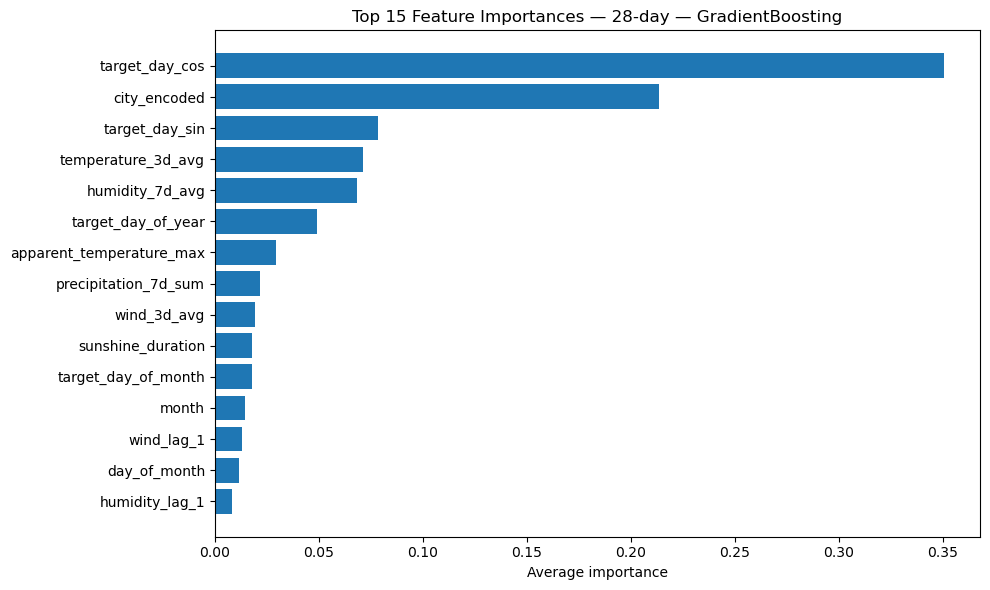

In [17]:
top_n = 15

plt.figure(figsize=(10, 6))
plt.barh(
    importance_28.head(top_n)["feature"][::-1],
    importance_28.head(top_n)["importance"][::-1]
)
plt.title(f"Top {top_n} Feature Importances — 28-day — {final_model_name}")
plt.xlabel("Average importance")
plt.tight_layout()
plt.show()

# 8. Prepare Latest Forecasting Base

## 8.1 — load forecast

In [18]:
forecast_df = run_query("SELECT * FROM raw.forecast").copy()
forecast_df["time"] = pd.to_datetime(forecast_df["time"])
forecast_df = forecast_df.sort_values(["city", "time"]).reset_index(drop=True)

print(forecast_df.shape)
print(forecast_df["time"].min(), "→", forecast_df["time"].max())
forecast_df.head()

(35, 9)
2026-04-28 00:00:00 → 2026-05-04 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city
0,2026-04-28,14.1,0.0,45.5,51,91,7.1,32312.05,Baku
1,2026-04-29,11.4,2.0,26.2,68,100,6.6,0.00,Baku
2,2026-04-30,17.8,0.0,19.7,62,45,19.1,45458.65,Baku
3,2026-05-01,17.6,0.0,35.1,81,33,14.0,48264.58,Baku
4,2026-05-02,19.4,0.0,27.0,80,42,17.2,46696.39,Baku


## 8.2 — combine historical + forecast

In [19]:
historical_raw = run_query("SELECT * FROM raw.historical").copy()
historical_raw["time"] = pd.to_datetime(historical_raw["time"])

forecast_raw = run_query("SELECT * FROM raw.forecast").copy()
forecast_raw["time"] = pd.to_datetime(forecast_raw["time"])

combined_for_future = pd.concat(
    [historical_raw, forecast_raw],
    ignore_index=True
)

combined_for_future = (
    combined_for_future
    .sort_values(["city", "time"])
    .drop_duplicates(subset=["city", "time"], keep="last")
    .reset_index(drop=True)
)

future_feature_df, future_le = build_features(combined_for_future)

latest_origin = (
    future_feature_df
    .sort_values(["city", "time"])
    .groupby("city")
    .tail(1)
    .reset_index(drop=True)
)

latest_origin[["city", "time"]]

,city,time
0,Baku,2026-05-04
1,Gabala,2026-05-04
2,Guba,2026-05-04
3,Lankaran,2026-05-04
4,Shaki,2026-05-04


# 9. Final 28-Day Hybrid Forecast

## 9.1 — train direct horizon models

In [20]:
def train_direct_horizon_models(df_input, horizons, model_name):
    trained = {}

    for h in horizons:
        print(f"Training {model_name} for horizon={h}...")

        df_sup = make_supervised(df_input, horizon=h)

        X_train_h = df_sup[horizon_feature_cols]
        y_train_h = df_sup[horizon_target_cols]

        model = models[model_name]
        model.fit(X_train_h, y_train_h)

        trained[h] = model

    return trained

## 9.2 — predict ML days 8–28

In [21]:
def predict_ml_days_after_api(latest_origin_df, training_df, model_name, ml_days=21):
    """
    Predict ML part of the final 28-day forecast.
    API covers days 1-7.
    ML covers days 8-28.
    """
    horizons = list(range(1, ml_days + 1))

    direct_models = train_direct_horizon_models(
        df_input=training_df,
        horizons=horizons,
        model_name=model_name
    )

    rows = []

    for _, origin_row in latest_origin_df.iterrows():
        city = origin_row["city"]
        origin_time = origin_row["time"]

        for h in horizons:
            target_time = origin_time + pd.Timedelta(days=h)

            row = origin_row.copy()

            row["target_time"] = target_time
            row["target_month"] = target_time.month
            row["target_day_of_month"] = target_time.day
            row["target_day_of_year"] = target_time.dayofyear
            row["target_day_sin"] = np.sin(2 * np.pi * target_time.dayofyear / 365.25)
            row["target_day_cos"] = np.cos(2 * np.pi * target_time.dayofyear / 365.25)

            X_future = pd.DataFrame([row])[horizon_feature_cols]
            pred = direct_models[h].predict(X_future)[0]

            result = {
                "city": city,
                "origin_time": origin_time,
                "forecast_horizon": h + 7,
                "target_time": target_time,
                "source": "ml_model",
            }

            for i, target in enumerate(target_cols):
                result[target] = pred[i]

            rows.append(result)

    return pd.DataFrame(rows)

## 9.3 — prepare API forecast days 1–7

In [22]:
def prepare_api_forecast_output(forecast_df):
    api_part = forecast_df.copy()
    api_part = api_part.sort_values(["city", "time"]).reset_index(drop=True)

    api_part["origin_time"] = api_part.groupby("city")["time"].transform("min") - pd.Timedelta(days=1)
    api_part["forecast_horizon"] = api_part.groupby("city").cumcount() + 1
    api_part["target_time"] = api_part["time"]
    api_part["source"] = "api_forecast"

    output_cols = [
        "city",
        "origin_time",
        "forecast_horizon",
        "target_time",
        "source",
    ] + target_cols

    return api_part[output_cols]

## 9.4 — build final 28-day forecast

In [23]:
api_7d = prepare_api_forecast_output(forecast_df)

ml_21d = predict_ml_days_after_api(
    latest_origin_df=latest_origin,
    training_df=df,
    model_name=final_model_name,
    ml_days=21
)

final_28d_forecast = pd.concat(
    [api_7d, ml_21d],
    ignore_index=True
).sort_values(["city", "target_time"]).reset_index(drop=True)

print(final_28d_forecast["target_time"].min(), "→", final_28d_forecast["target_time"].max())
print(final_28d_forecast.groupby(["city", "source"]).size())

final_28d_forecast.head(35)

Training GradientBoosting for horizon=1...
Training GradientBoosting for horizon=2...
Training GradientBoosting for horizon=3...
Training GradientBoosting for horizon=4...
Training GradientBoosting for horizon=5...
Training GradientBoosting for horizon=6...
Training GradientBoosting for horizon=7...
Training GradientBoosting for horizon=8...
Training GradientBoosting for horizon=9...
Training GradientBoosting for horizon=10...
Training GradientBoosting for horizon=11...
Training GradientBoosting for horizon=12...
Training GradientBoosting for horizon=13...
Training GradientBoosting for horizon=14...
Training GradientBoosting for horizon=15...
Training GradientBoosting for horizon=16...
Training GradientBoosting for horizon=17...
Training GradientBoosting for horizon=18...
Training GradientBoosting for horizon=19...
Training GradientBoosting for horizon=20...
Training GradientBoosting for horizon=21...
2026-04-28 00:00:00 → 2026-05-25 00:00:00
city      source      
Baku      api_foreca

,city,origin_time,forecast_horizon,target_time,source,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean
0,Baku,2026-04-27,1,2026-04-28,api_forecast,14.100000,0.000000,45.500000,51.000000,91.000000
1,Baku,2026-04-27,2,2026-04-29,api_forecast,11.400000,2.000000,26.200000,68.000000,100.000000
2,Baku,2026-04-27,3,2026-04-30,api_forecast,17.800000,0.000000,19.700000,62.000000,45.000000
3,Baku,2026-04-27,4,2026-05-01,api_forecast,17.600000,0.000000,35.100000,81.000000,33.000000
4,Baku,2026-04-27,5,2026-05-02,api_forecast,19.400000,0.000000,27.000000,80.000000,42.000000
5,Baku,2026-04-27,6,2026-05-03,api_forecast,21.700000,0.000000,20.200000,71.000000,69.000000
6,Baku,2026-04-27,7,2026-05-04,api_forecast,24.200000,0.000000,54.000000,66.000000,84.000000
7,Baku,2026-05-04,8,2026-05-05,ml_model,21.792627,2.235353,25.020777,72.054071,58.981314
8,Baku,2026-05-04,9,2026-05-06,ml_model,21.761843,2.235353,25.020777,72.054071,58.981314
9,Baku,2026-05-04,10,2026-05-07,ml_model,21.761843,2.235353,25.020777,72.054071,58.981314


# 10. Save Forecast Output

In [24]:
conn = get_connection()
conn.register("final_28d_forecast_view", final_28d_forecast)

conn.execute("""
CREATE SCHEMA IF NOT EXISTS analytics;
""")

conn.execute("""
CREATE OR REPLACE TABLE analytics.final_28d_forecast AS
SELECT * FROM final_28d_forecast_view;
""")

conn.close()

run_query("SELECT * FROM analytics.final_28d_forecast LIMIT 10")

,city,origin_time,forecast_horizon,target_time,source,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean
0,Baku,2026-04-27,1,2026-04-28,api_forecast,14.100000,0.000000,45.500000,51.000000,91.000000
1,Baku,2026-04-27,2,2026-04-29,api_forecast,11.400000,2.000000,26.200000,68.000000,100.000000
2,Baku,2026-04-27,3,2026-04-30,api_forecast,17.800000,0.000000,19.700000,62.000000,45.000000
3,Baku,2026-04-27,4,2026-05-01,api_forecast,17.600000,0.000000,35.100000,81.000000,33.000000
4,Baku,2026-04-27,5,2026-05-02,api_forecast,19.400000,0.000000,27.000000,80.000000,42.000000
5,Baku,2026-04-27,6,2026-05-03,api_forecast,21.700000,0.000000,20.200000,71.000000,69.000000
6,Baku,2026-04-27,7,2026-05-04,api_forecast,24.200000,0.000000,54.000000,66.000000,84.000000
7,Baku,2026-05-04,8,2026-05-05,ml_model,21.792627,2.235353,25.020777,72.054071,58.981314
8,Baku,2026-05-04,9,2026-05-06,ml_model,21.761843,2.235353,25.020777,72.054071,58.981314
9,Baku,2026-05-04,10,2026-05-07,ml_model,21.761843,2.235353,25.020777,72.054071,58.981314
